In [1]:
from IPython.display import Image

#  (지역) 특성 

## 5. 특징점 매칭

- 둘 또는여러개의 이미지에서 동일한 위치에 해당하는 특징점을 찾음
- 다양한 응용에 활용 됨.  

   - 로보틱스 및 자율 주행: SLAM (Simultaneous Localization and Mapping), Visual Odometry
   - 3차원 복원 및 증강 현실 (3D Reconstruction & AR): SfM (Structure from Motion), 이미지 스티칭 (Panorama), 
증강 현실 (AR)
   - 객체 인식 및 추적 (Object Recognition & Tracking): 이미지 검색(구글 렌즈), 물체 추적  
   - 검사 및 보안 (Inspection & Security): 정상품과의 비교, 생체 인식(지문이나 홍채의 고유한 특징점)
   - 영상 콘텐츠 분석 (Media Content Analysis): 비디오 스테빌라이제이션 (Stabilization), 영화 시각 효과 (VFX)

#### 매칭 방법

- 문제의 수학적 정의 
   - 일반적으로 기술자는 n 차원 백터
   - 검색
       - 기술자들의 집합 $ D = \{ d_i \} $ 에서 $d_t$와 가장거리가 작은 원소를 찾아내는 것
       
$$ d_{min} = \arg\min_{di \in D } \| d_i - d_t \|^2 $$
   - 매칭
       -  $ D_1 = \{ d_i \} $의 모든 원소에 대해 $D_2$의 모든 원소를 대응 시키는 것 
       -  보통은 원소의 갯수가 동일하지 않은 경우가 많기 때문에 1:1 매칭은 아님.
 
-  어려운 점
   - 대상이 매우 많다. 즉 집합이 크다. (수백 에서 수억, 요즘은 수경 까지)
   - 값에 오차가 섞여있는 경우가 많다.
   
 

### 해결법

  - brute-force 방식: 모든 경우를 다 따지는 방법
      
      - $D_1$의 모든 원소에 대해 $D_2$의 모든 원소의 거리를 계산하여 가작 작은 것을 선택함. (완벽)
      
      $ \{ (d_{min} (d_t), d_t) \}$ where $ d_{min} (d_t) = \arg\min_{d_i \in D_1 } \| d_i - d_t \|^2$  for $t  \in D_2$
      
      - 계산 복잡도: $O(N^2)$의 비용이 발생하여 특징점 개수가 커지면 (100개 이상) 매우 느려짐

      
   - kd-Tree
      - 기본 알고리즘  
          - 이진 검색의 방식을 k 차원으로 확장한 방식.
          - 가장 분산이 큰 축을 계산.
          - 해당 축으로 이진 분류 
          - 각 그룹별로 가장 분산이 큰 축을 계산 
          - 해당 축을 기준으로 이진분류 
          - 원소가 하나가 남을때 까지 반복 
      - 매번 분산을 계산하는 것이 어려운 경우가 있고, 기준 축이 데이터에 따라 달라짐
          - 간단히, 축을 순차적으로 선택하는 방법으로 단순화 
    


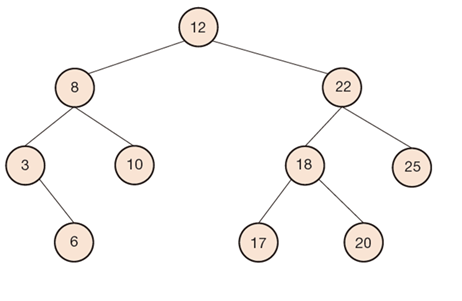

In [7]:
Image("binarytree.png", width=360)

  - 최적의 분류가 아님.
      - 한번 윗단계에서 잘못분류된 경우 이를 수정하기위한 back-tracking 사용됨.
      - 경우에 따라 맨 처음 단계로 back-tracking하는 경우가 발생: 횟수를 제한함
      

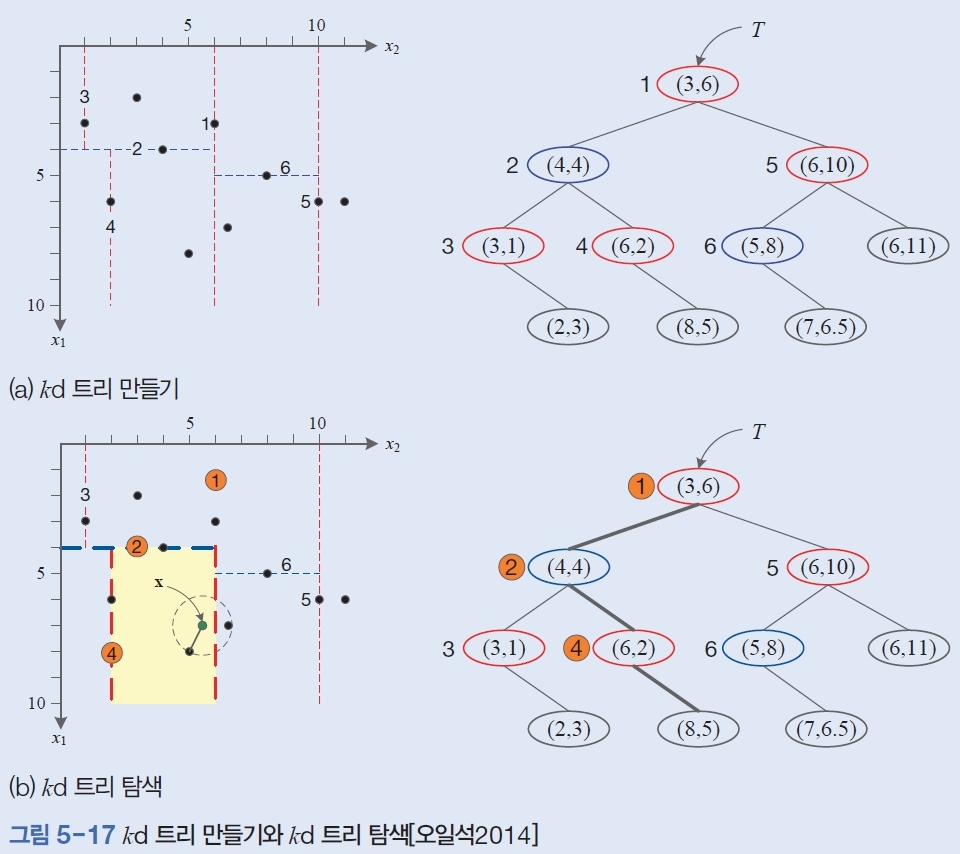

In [8]:
Image("그림 5-17.jpg", width=480)

###  OpenCV에서 매칭의 지원 

- Brute Force와 KDTree 모두지원 

#### Brute-Force Matcher 
- 매처 생성: bf = cv2.BFMatcher(normType, crossCheck)
    - normType: 거리 측정 방식.
        - SIFT/SURF는 cv2.NORM_L2
        - ORB/BRIEF 같은 이진 기술자는 cv2.NORM_HAMMING
    - crossCheck: True로 설정하면 양방향 매칭 결과가 일치하는 것만 반환하여 신뢰도를 높입
- 매칠 실행: matches = bf.match(des1, des2)

####  FLANN (Fast Library for Approximate Nearest Neighbors) 기반 Matcher 
- KD-Tree를 포함 대량의 데이터셋에서 빠르게 **근사** 근접 이웃을 찾기 위한 라이브러리

- FlannBasedMatcher 객체 생성: flann = cv2.FlannBasedMatcher(index_params, search_params)
    - index_params:  기본 알고리즘 세팅, 예)  dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
    - search_params: 추가 알고리즘 세팅, 예) dict(checks=50) 
- 매칭 수행: matches = flann.knnMatch(des1, des2, k=2)
    - desc1 쪽의 각 데이터(query) 기준 desc2 집합(gallery, train, scene)에서 가장 가까운 최대 k개의 데이터를 추출
    

(<Axes: title={'center': 'test image'}>,
 (-0.5, 959.5, 539.5, -0.5),
 Text(0.5, 1.0, 'test image'))

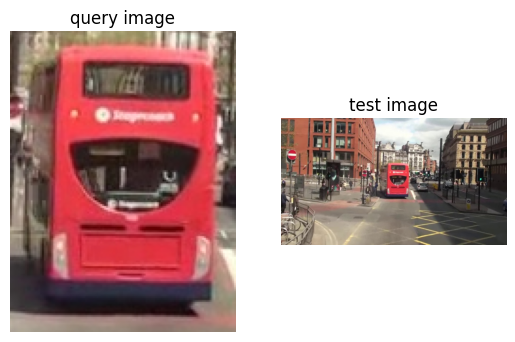

In [9]:
# 1. 이미지 준비 
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_query_base = cv2.imread('mot_color70.jpg')
img_query = img_query_base[190:350,440:560] # 버스를 크롭하여 모델 영상으로 사용
gray_query=cv2.cvtColor(img_query,cv2.COLOR_BGR2GRAY)
img_train=cv2.imread('mot_color83.jpg')   # 장면 영상
gray_train=cv2.cvtColor(img_train,cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1), plt.imshow(img_query[:,:,::-1]), plt.axis('off'), plt.title("query image")
plt.subplot(1,2,2), plt.imshow(img_train[:,:,::-1]), plt.axis('off'), plt.title("test image")

num: 231,4096


(<Axes: title={'center': 'test image'}>,
 (-0.5, 959.5, 539.5, -0.5),
 Text(0.5, 1.0, 'test image'))

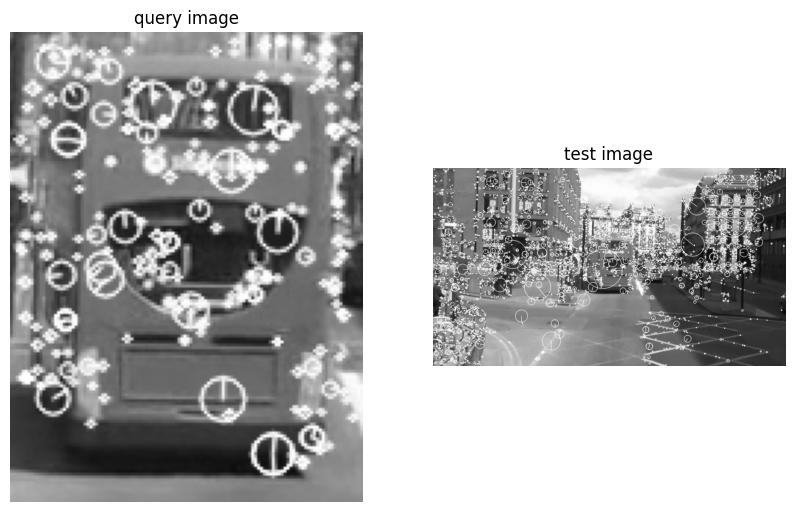

In [10]:
# 2. 특징점 검출 및 기술자 생성  
sift=cv2.SIFT_create()
kp1,des1=sift.detectAndCompute(gray_query,None)
kp2,des2=sift.detectAndCompute(gray_train,None)
print(f"num: {len(kp1)},{len(kp2)}")

img_ann1 = cv2.drawKeypoints(gray_query, kp1, None, color=(255,255,255), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  
img_ann2 = cv2.drawKeypoints(gray_train, kp2, None, color=(255,255,255), flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)  
plt.figure(figsize = (10,12))
plt.subplot(1,2,1), plt.imshow(img_ann1), plt.axis('off'), plt.title("query image")
plt.subplot(1,2,2), plt.imshow(img_ann2), plt.axis('off'), plt.title("test image")

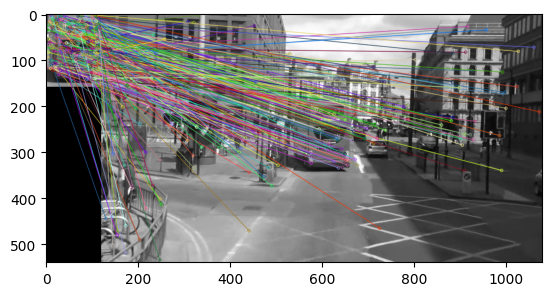

In [15]:
# 3. Matching 
flann_matcher=cv2.DescriptorMatcher_create(cv2.DescriptorMatcher_FLANNBASED)
knn_match=flann_matcher.knnMatch(des1,des2,2)

# 매칭 결과 시각화
# 가장 잘 맞은 것만  
good_matches1 = []
for first, second in knn_match:
    good_matches1.append(first)
    
img_match_raw = cv2.drawMatches(gray_query, kp1, gray_train, kp2, good_matches1, None, 
                      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_match_raw[:,:,::-1])

#### 잘못된 매칭을 필터링하는 방법 중
 -  가장 큰것이 두번째 보다 월등히 큰지를 보는 방법
 

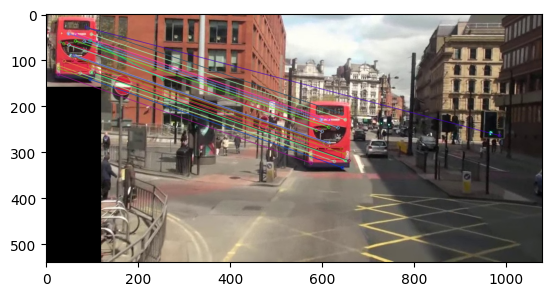

In [18]:
T=0.7
good_matches2=[]
for first, second in knn_match:
    if (first.distance/second.distance)<T:
        good_matches2.append(first)

# 매칭 결과 시각화
img_match_compare = cv2.drawMatches(img_query, kp1, img_train, kp2, good_matches2, None, 
                      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_match_compare[:,:,::-1])

### 6. 호모그라피 추정  

- 매칭 오류 
     - 앞서 매칭결과를 보면 상당히 많은 매칭이 오류 (약50% 옳은 매칭)
     - 가장 큰것과 두번째 큰것의 차를 가지고 필터링해도 여전히 (80% 정도만 옳은 매칭) 
     - 개별적인 데이터만을 가지고 오류를 찾음 
     
- 특징점들 전체를 위치를 고려한 통합 필터링 
    - 또한 Homography를 추정하는데도 사용됨
    

####  3D-2D projection (Perspective Projection)

  - 3차원 공간상의 점 $ P(Z, Y, X) $가 카메라에 $p(y, x)$ (물리공간) 또는 $p(v,u)$ (화소공간) 투영
  - 행렬 (3x4/4x5)의 행렬  $ p = M_{3Dto2D} \cdot P $ 
  - 일반적으로 역의 행렬 ($ p(y,x)$ -> $P(Z, Y, X) $은 존재 하지 않음 
       - 여러 위치에서 촬영된 카메라를 사용하여야 복원 가능(SfM, structure from motion)

#### 호모그라피 (Homography = Perspective transform)
  
  - 대상 점들이 3차원공간에서 평면상에 있거나, 카매라가 같은 위치에서 회전만 하는 경우 
  - 두개의  프로젝션 점에 대한 대응 관계는 동차 행렬으로 표현이 가능     
      
      $$ {p^T}_2 = H_{1,2} {p^T}_1$$  
      $$ p_1 = (y_1,x_1,1), p_2 = (y2_, x_2, 1)$$
      $$H_{1,2}= \begin{bmatrix} h_{1,1} & h_{1,2} & h_{1,3} \\ h_{2,1} & h_{2,2} & h_{2,3} \\ h_{3,1} & h_{3,2} & 1 \end{bmatrix}$$
       - 8 DOF (8개의 변수를 사용)

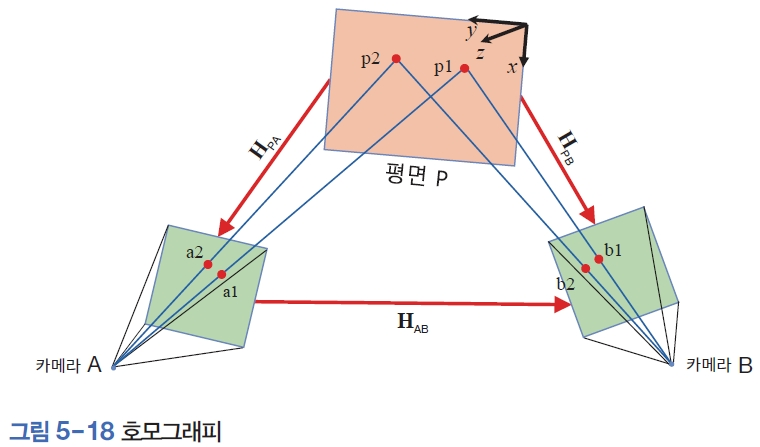

In [4]:
Image("그림 5-18.jpg", width=480)

### 호모그래피 행렬을 구하는 방법

 - 8개의 미지수 => 최소 8개의 방정식 => 4개의 매칭점
 - 이론상은 정확히 나와야 하나, 측정및 계산 오차 때문에 그렇지 못함
 
#### 1. Mean Squared Error 최소화 방법 
    
$$\hat{H_{1,2}} = \arg\min_{H} \sum \| p_1(n) H - p_2(n) \|^2 $$
 
 
    - 일반적으로 전자공학에서 Gaussian 노이즈를 가정하는 경우 자주 사용하는 방법
    - 실제로는 이상치 (outlier)가 없는 경우에만 효과적 

#### 2. RANSAC (RADNDOM Consensus)

 - 알고리즘 
    - 랜던하게 변수를 구할수 있는 최소한의 관측을 선택 (Homography 는 4개)
    - 이 관측을 가지고 변수 계산 (역행렬 방식으로 계산)
    - 이 계산결과와 부합하는 관측의 수를 계수
    - 이를 N 번수행하여 이중에서 가장 부합하는 관측이 많은 경우를 추정치로 선택 
    
 - 특징 
     - 이상치가 있는 경우에 매우 효과적 
     - 원하는 오류률을 정하면 필요한 반복횟수 $N$이 정해짐 
    

H: [[1.20971428e+00 3.64763204e-02 4.25511080e+02]
 [6.39280235e-02 1.09775699e+00 1.81891583e+02]
 [2.71606685e-04 4.05956909e-05 1.00000000e+00]]


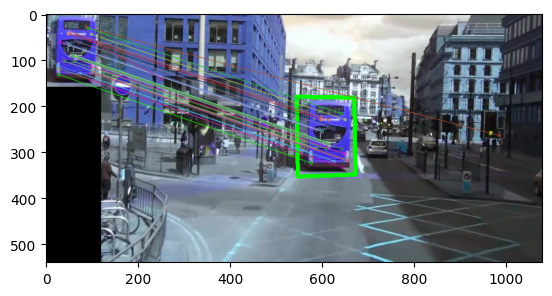

In [26]:
points1=np.float32([kp1[gm.queryIdx].pt for gm in good_matches2])
points2=np.float32([kp2[gm.trainIdx].pt for gm in good_matches2])
H, mask=cv2.findHomography(points1,points2,cv2.RANSAC)
print("H:", H)


h1,w1=img_query.shape[0],img_query.shape[1] 
h2,w2=img_train.shape[0],img_train.shape[1] 
box1=np.float32([[0,0],[0,h1-1],[w1-1,h1-1],[w1-1,0]]).reshape(4,1,2) # query 이미지 
box2=cv2.perspectiveTransform(box1,H)  # Perspective 변환 
img2=cv2.polylines(img_train,[np.int32(box2)],True,(0,255,0),8)  # box 위치 표시 

# 위에서 구한 good match를 사용함: 여전히 잘못된 것이 보임.  
img_match=np.empty((max(h1,h2),w1+w2,3),dtype=np.uint8)
cv2.drawMatches(img_query,kp1,img_train,kp2,good_matches2,img_match,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_match)

ransaced: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1]


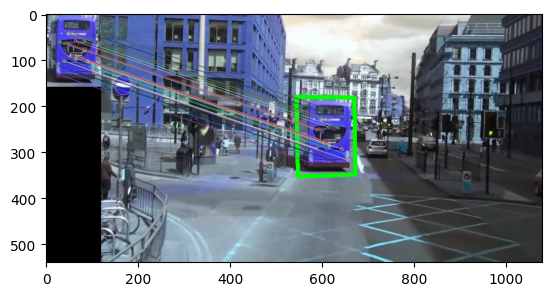

In [28]:
ransac_mask_matches = mask.ravel().tolist() # list(mask.flatten())
print("ransaced:", ransac_mask_matches)

draw_params = dict( #matchColor = (0,255,0),
                   singlePointColor = None,
                   matchesMask = ransac_mask_matches, flags = 2)                 
img_match_with_homo = cv2.drawMatches(img_query, kp1, img_train,kp2, good_matches2, None,**draw_params)
plt.imshow(img_match_with_homo)

### 끝